In [1]:
import tensorflow
import seaborn
import sklearn
print(tensorflow.__version__)
print(seaborn.__version__)
print(sklearn.__version__)

##unified-ai
# 2.21.0
# 0.13.2
# 1.3.2

#google-colabs
# 2.20.0
# 0.13.2
# 1.6.1

I0000 00:00:1777755752.770287     380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777755753.892335     380 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777755757.774786     380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.21.0
0.13.2
1.3.2


In [2]:
import pathlib
import numpy as np

In [3]:
!mkdir -p /home/jovyan/data/dataset_dollarstreet #unified-ai
# !mkdir -p /content/data/dataset_dollarstreet #google-colabs

In [4]:
# unified-ai
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/test_images.npy
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/test_labels.npy
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/train_images.npy
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/train_labels.npy

# #google-colabs
# !wget -nc -P /content/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/test_images.npy
# !wget -nc -P /content/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/test_labels.npy
# !wget -nc -P /content/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/train_images.npy
# !wget -nc -P /content/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/train_labels.npy

File ‘/home/jovyan/data/dataset_dollarstreet/test_images.npy’ already there; not retrieving.

File ‘/home/jovyan/data/dataset_dollarstreet/test_labels.npy’ already there; not retrieving.

File ‘/home/jovyan/data/dataset_dollarstreet/train_images.npy’ already there; not retrieving.

File ‘/home/jovyan/data/dataset_dollarstreet/train_labels.npy’ already there; not retrieving.



In [5]:
DATA_FOLDER = pathlib.Path('/home/jovyan/data/dataset_dollarstreet') #unified-ai
# DATA_FOLDER = pathlib.Path('/content/data/dataset_dollarstreet') #google-colabs

train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels = np.load(DATA_FOLDER / 'test_labels.npy')

In [6]:
train_images = train_images / 255.0
val_images = val_images / 255.0

In [7]:
# input tensor
from tensorflow import keras
keras.utils.set_random_seed(2)

inputs = keras.Input(train_images.shape[1:])

In [8]:
# upscale layer
import tensorflow as tf
method = tf.image.ResizeMethod.BILINEAR
upscale = keras.layers.Lambda(
  lambda x: tf.image.resize_with_pad(x, 160, 160, method=method))(inputs)

In [9]:
base_model = keras.applications.DenseNet121(include_top=False,
                                            pooling='max',
                                            weights='imagenet',
                                            input_tensor=upscale,
                                            input_shape=(160,160,3),
                                            )

E0000 00:00:1777755761.589547     380 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
base_model.trainable = False

In [11]:
out = base_model.output
out = keras.layers.Flatten()(out)
out = keras.layers.BatchNormalization()(out)
out = keras.layers.Dense(50, activation='relu')(out)
out = keras.layers.Dropout(0.5)(out)
out = keras.layers.Dense(10)(out)

In [12]:
model = keras.models.Model(inputs=inputs, outputs=out)

In [13]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 166, 166,  │          0 │ lambda[0][0]      │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 80, 80,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 80, 80,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 80, 80,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 82, 82,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 40, 40,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 40, 40,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 40, 40,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 40, 40,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 40, 40,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 40, 40,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 40, 40,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 40, 40,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 40, 40,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 40, 40,    │          0 │ conv2_block2_0_b

 Total params: 7,093,360 (27.06 MB)

 Trainable params: 53,808 (210.19 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [14]:
model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [15]:
early_stopper = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                              patience=5)

In [16]:
import time

# Start the timer
start_time = time.time()

history = model.fit(
    x=train_images,
    y=train_labels,
    batch_size=128,
    epochs=10,
    callbacks=[early_stopper],
    validation_data=(val_images, val_labels)
)

# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 248s 36s/step - accuracy: 0.1378 - loss: 2.6944 - val_accuracy: 0.0990 - val_loss: 4.0473
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 236s 35s/step - accuracy: 0.2608 - loss: 2.1209 - val_accuracy: 0.1672 - val_loss: 3.2438
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 245s 36s/step - accuracy: 0.3770 - loss: 1.7953 - val_accuracy: 0.2218 - val_loss: 2.7143
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 242s 36s/step - accuracy: 0.4339 - loss: 1.6101 - val_accuracy: 0.2833 - val_loss: 2.4003
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 240s 35s/step - accuracy: 0.5091 - loss: 1.4394 - val_accuracy: 0.3447 - val_loss: 2.2489
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 241s 36s/step - accuracy: 0.5456 - loss: 1.3127 - val_accuracy: 0.3584 - val_loss: 2.0969
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 243s 36s/step - accuracy: 0.6014 - loss: 1.1915 - val_accuracy: 0.3720 - val_loss: 1.9863
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 243s 36s/step - accuracy: 0.6424 - loss: 1.0875 - val_accuracy: 0.3925 - val_loss:

In [17]:
#LOGS

# unified-ai 2cpu, 4GB RAM
#   model.fit( ... ,batch_size=128, epochs=10, ...) in 
#   Training completed in 2441.25 seconds or 40.69 minutes

# unified-ai 2cpu, 12GB RAM
#   model.fit( ... ,batch_size=128, epochs=10, ...) in 
#   Training completed in ?????????????????????


# unified-ai 4cpu, 8GB RAM
#   model.fit( ... ,batch_size=128, epochs=10, ...) in 
#   Training completed in 1256.71 seconds (20.95 minutes)

# unified-ai 4cpu, 16GB RAM
#   model.fit( ... ,batch_size=128, epochs=10, ...) in 
#   Training completed in ?????????????????????

# google-colabs 2 vCPUs (Xeon-class), ~12 GB RAM, Disk: ~30-100 GB temporary storage
#   model.fit( ... ,batch_size=128, epochs=10, ...) in 
#   Training completed in 1325.24 seconds (22.09 minutes)
 

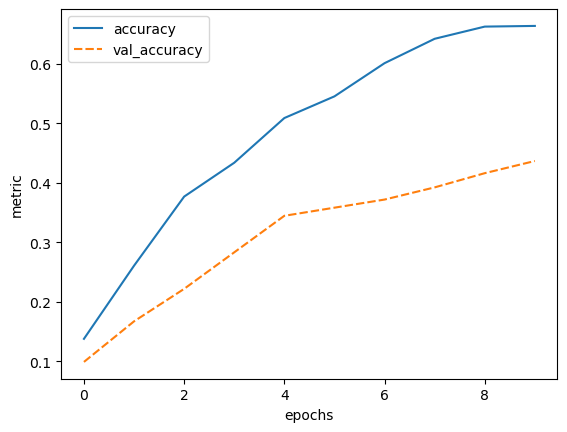

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (keras History object that is returned by model.fit())
        metrics(str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")
    plt.ylabel("metric")

plot_history(history, ['accuracy', 'val_accuracy'])